In [1]:
import torch
import numpy as np
import h5py
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from time import time

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/home/aadam/environments/scope/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, path_to_h5, key, channels, channels_last=False, device=DEVICE):
        self.filepath = path_to_h5
        self.device = device
        self.key = key
        self.channels = channels
        self.channels_last = channels_last
        self.hf = h5py.File(self.filepath, "r")
        self.size = self.hf[self.key].shape[0]

    def __len__(self):
        return self.size

    def __getitem__(self, index):
        if self.channels_last:
            im = torch.tensor(self.hf[self.key][index, :, :, self.channels]).to(self.device)
            # put channels first for Conv2D score model
            return torch.permute(im, (2, 0, 1))
        else:
            return torch.tensor(self.hf[self.key][index, self.channels]).to(self.device)

In [18]:
dataset_path = "/home/aadam/scratch/skirt512_grizy.h5"
dataset_key = "images"
dataset_channels = [0]
batch_size = 4
shuffle = False

dataset = Dataset(dataset_path, dataset_key, dataset_channels, channels_last=True, device=DEVICE)

# Benchmark with shuffle

In [19]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [20]:
%%timeit
for x in dataloader:
    break

1.8 s ± 354 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Benchmark iterating in order

In [21]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [22]:
%%timeit
for x in dataloader:
    break

17.8 ms ± 157 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Testing new idea iterating over dataset

In [11]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [00:32<00:00, 30.32it/s]

Took 32.9851450920105 seconds


Text(0.5, 0, 'Iterations')

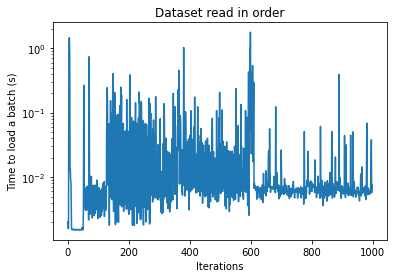

In [12]:
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

In [13]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [05:13<00:00,  3.19it/s]

Took 313.65667963027954 seconds


Text(0.5, 0, 'Iterations')

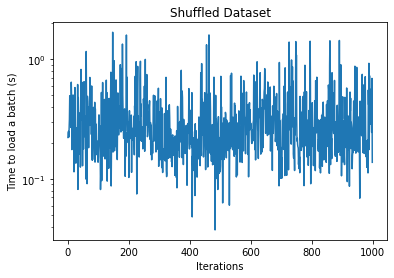

In [14]:
plt.title("Shuffled Dataset")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

# Larger batch size

In [7]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")

100%|██████████| 1000/1000 [15:05<00:00,  1.10it/s] 

Took 905.6564910411835 seconds


Text(0.5, 0, 'Iterations')

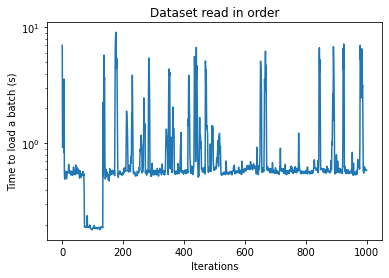

In [8]:
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

# Dataset made with smaller images

## 64^2 pixels

In [4]:
dataset_path = "/home/aadam/scratch/skirt64_grizy.h5"
batch_size = 32
dataset = Dataset(dataset_path, dataset_key, dataset_channels, device=DEVICE)

100%|██████████| 1000/1000 [00:12<00:00, 77.56it/s]

Took 12.900525569915771 seconds


Text(0.5, 0, 'Iterations')

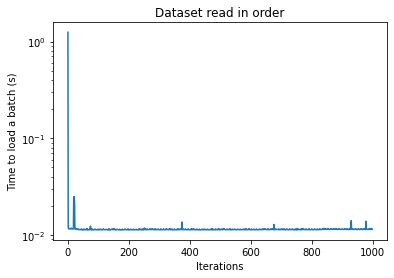

In [5]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

In [14]:
!cp /home/aadam/scratch/skirt64_grizy.h5 $SLURM_TMPDIR/skirt64_grizy.h5

In [15]:
!echo $SLURM_TMPDIR

/localscratch/aadam.37485006.0


In [23]:
dataset_path = "/localscratch/aadam.37485006.0/skirt64_grizy.h5"
batch_size = 32
dataset = Dataset(dataset_path, dataset_key, dataset_channels, device=DEVICE)

100%|██████████| 1000/1000 [00:24<00:00, 40.26it/s]

Took 24.843842029571533 seconds


Text(0.5, 0, 'Iterations')

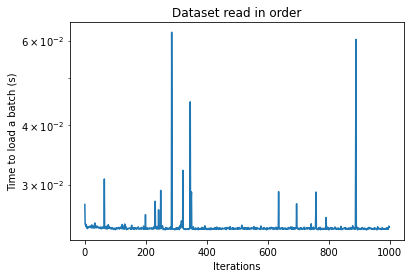

In [21]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

## 128^2 pixels

In [27]:
dataset_path = "/home/aadam/scratch/skirt128_grizy.h5"
batch_size = 16
dataset = Dataset(dataset_path, dataset_key, dataset_channels, device=DEVICE)

100%|██████████| 1000/1000 [00:41<00:00, 24.38it/s]

Took 41.03294897079468 seconds


Text(0.5, 0, 'Iterations')

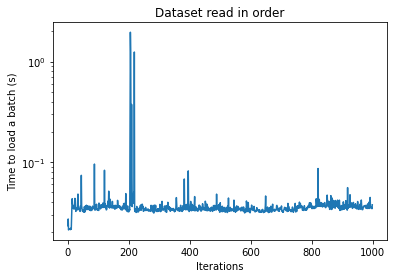

In [11]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")

## 256^2 pixels

In [32]:
dataset_path = "/home/aadam/scratch/skirt256_grizy.h5"
batch_size = 8
dataset = Dataset(dataset_path, dataset_key, dataset_channels, device=DEVICE)

100%|██████████| 1000/1000 [01:36<00:00, 10.39it/s]

Took 96.24332046508789 seconds


Text(0.5, 0, 'Iterations')

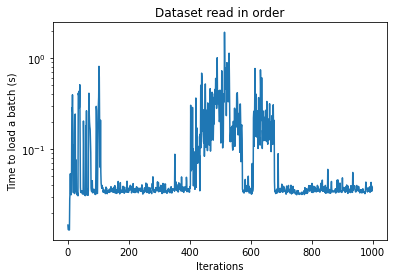

In [13]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
data_iter = iter(dataloader)

num_epochs = 1
epoch_iterations = 1000
epoch_time = []
loading_time = []

global_start = time()
for e in range(num_epochs):
    for batch in tqdm(range(epoch_iterations)):
        start = time()
        try:
            x = next(data_iter)
        except StopIteration:
            print(f"reached end of dataset at epoch {e}")
            # End of dataset reached, reset the iterator
            data_iter = iter(dataset)
            x = next(data_iter)
        loading_time.append(time() - start)
    epoch_time.append(time() - start)    

print(f"Took {(time() - global_start)} seconds")
plt.title("Dataset read in order")
plt.semilogy(loading_time)
plt.ylabel("Time to load a batch (s)")
plt.xlabel("Iterations")